# Hallucination Detection via Semantic Entropy & Embedding Geometry
## Exploratory Data Analysis: All Datasets

This notebook performs EDA across five QA benchmarks. For each dataset it shows:
response-level label breakdowns, domain statistics, and hallucination rate visualisations.
A combined section analyses all ~2500 questions together.

### Dataset Descriptions

| Dataset | Questions | Focus |
|---------|-----------|-------|
| **DefAn** | 500 | Definitional-answer questions testing factual grounding |
| **HaluEval** | 500 | Curated hallucination pairs (Wikipedia, dialogue, QA) |
| **MMLU** | 500 | Massive Multitask Language Understanding: 57 subjects |
| **TriviaQA** | 500 | Trivia-style reading-comprehension with evidence documents |
| **TruthfulQA** | 500 | Questions designed to elicit common human misconceptions |

All responses were generated with **Llama-3.2-3B** (temperature 0.9 for DefAn, 1.0 for others, N=20 samples/question)
on a Colab H100 GPU, and labelled by **GPT-4.1-nano** running on a CPU runtime.

**Estimated generation time:** 

=> We ran Llama-3.2-3B on an H100.  In this hardware achieves roughly 1500–2000 tokens/s in batched mode.
With 2500 questions × 20 responses × ~100 tokens/response = 5 M tokens, theoretically this would take under an hour 
but generation in practice took approximately **8-10 hours**. 

=> Judging was performed by GPT-4.1-nano (50 000 API calls) took roughly **20 hours**, using the Openai API Platform

### Domain Validity

Domains are **LLM-generated labels** assigned by the judge, not METADATA 

This creates several problems:

1. **Label noise / inconsistency:** (14–36% of questions are domain-inconsistent). We use
   majority-vote (`domain_mode`).
2. **Uniform sampling confound:** Questions were drawn uniformly from each benchmark,
   not stratified by domain. The domain distribution reflects whatever the benchmark happens
   to cover.
3. **Domain diversity:** TruthfulQA (90 domains), TriviaQA/MMLU (64–65), HaluEval (30)
   produce many sub-groups too small for statistical inference.
4. **Spurious correlations:** Domain assignment may correlate with hallucination rate for
   reasons unrelated to subject matter.

**Consequence:** All domain-level results are exploratory and descriptive only.

=> Benchmark-level statistics (run on ~500 per dataset) and the combined analysis
(2500) are the primary datasets.

## Setup

In [1]:
import sys, os
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from spectral_detection.data.cleaning import (
    load_dataset, add_canonical_domain, compute_question_metadata,
    questions_per_domain, FEATURES, FEATURE_LABELS, LABEL_ORDER,
)
from spectral_detection.analysis.eda import print_loading_summary, print_domain_consistency
from spectral_detection.visualization import (
    plot_response_label_breakdown,
)


## Configuration

In [2]:
DATA_DIR   = '../data/processed'
OUTPUT_DIR = '../data/processed/temp/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

DATASET_FILES = {
    'defan':      'defan_t0.9_n20.jsonl',
    'halueval':   'halueval_t1.0_n20.jsonl',
    'mmlu':       'mmlu_t1.0_n20.jsonl',
    'triviaqa':   'triviaqa_t1.0_n20.jsonl',
    'truthfulqa': 'truthfulqa_t1.0_n20.jsonl',
}
# DefAn domains are stable; others need canonical consolidation
USE_CANONICAL = {'defan': False, 'halueval': True, 'mmlu': True,
                  'triviaqa': True, 'truthfulqa': True}

---
## Per-Dataset EDA

Each dataset gets: loading summary, domain consistency check, and response-label breakdown.

For datasets other than DefAn, domain labels suffer from sprawl (30-90 raw strings).
We consolidate to canonical top-level categories.

**Reading the label breakdown charts:** each horizontal bar is a domain. The blue
segment shows the fraction of responses labelled correct, red = incorrect (hallucinated),
orange = refused. A domain dominated by red/orange signals high hallucination propensity
for that topic.


  DEFAN
Dataset:          defan
Total rows:       10000
Unique questions: 500
Samples/question: min=20, max=20, median=20.0

Correctness distribution:
  correct     :   2377  (23.8%)
  incorrect   :   7621  (76.2%)
  refused     :      2  (0.0%)

Domains (7 unique):
  Humanities
  Law, Business, and Miscellaneous
  Medicine & Health
  STEM
  Science & Technology
  Social Sciences
  Sports

Answer types: ['city', 'date', 'name', 'numeric']
Domain inconsistency: 70/500 questions (14.0%)
Max unique domains per question: 3

Questions per domain (top 10):


domain
Humanities                          203
Social Sciences                     166
STEM                                140
Sports                               49
Medicine & Health                    16
Science & Technology                  2
Law, Business, and Miscellaneous      1
Name: prompt_id, dtype: int64

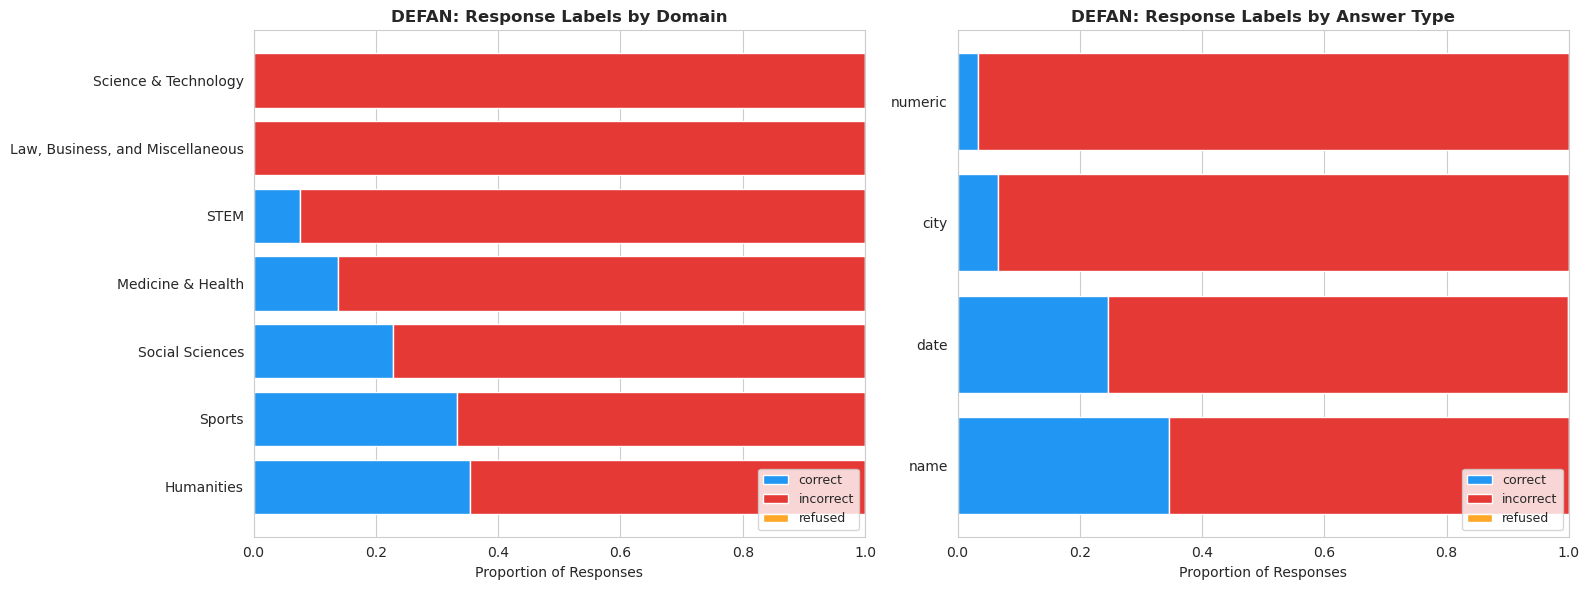


  HALUEVAL
Dataset:          halueval
Total rows:       10000
Unique questions: 500
Samples/question: min=20, max=20, median=20.0

Correctness distribution:
  correct     :   8984  (89.8%)
  incorrect   :   1006  (10.1%)
  refused     :     10  (0.1%)

Domains (30 unique)  (showing 10 of 30):
  Business
  Business, Food & Beverage
  Business, Hospitality, Entertainment
  Business, Industry, and Miscellaneous
  Business, Law, and Miscellaneous
  Business, Miscellaneous
  Business, Non-profit
  Business, Social Sciences
  Business, Technology
  Business, and Miscellaneous
  ...
Domain inconsistency: 95/500 questions (19.0%)
Max unique domains per question: 3

Questions per domain (top 10):


domain_canonical
Humanities           276
STEM                 122
Social Sciences      115
Entertainment         37
Law & Business        27
Sports                19
Medicine & Health      7
Food & Nutrition       2
History                1
Name: prompt_id, dtype: int64

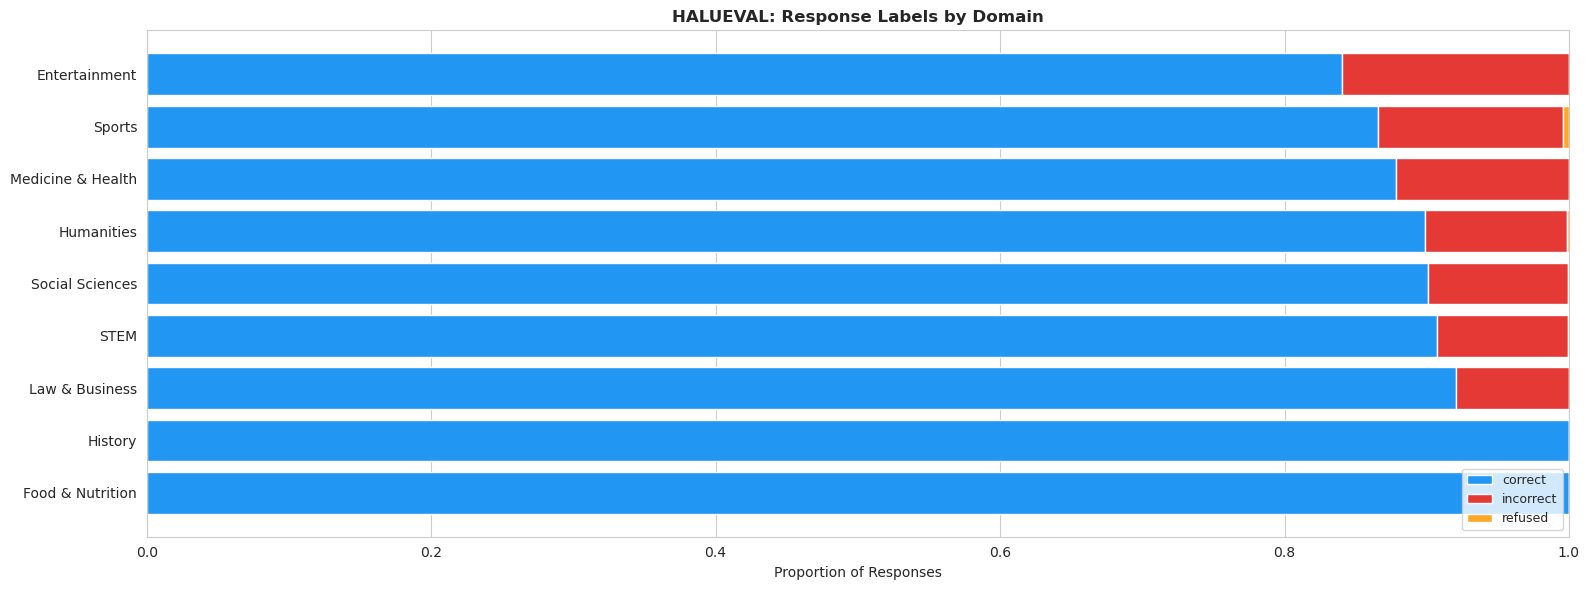


  MMLU
Dataset:          mmlu
Total rows:       10000
Unique questions: 500
Samples/question: min=20, max=20, median=20.0

Correctness distribution:
  correct     :   2732  (27.3%)
  incorrect   :   7267  (72.7%)
  refused     :      1  (0.0%)

Domains (65 unique)  (showing 10 of 65):
  Biology
  Business
  Business, Economics, and Marketing
  Business, Finance, and Accounting
  Business, Finance, and Economics
  Business, Finance, and Miscellaneous
  Business, Law, and Miscellaneous
  Business, Management, and Miscellaneous
  Business, Marketing
  Business, Marketing, and Economics
  ...
Domain inconsistency: 168/500 questions (33.6%)
Max unique domains per question: 5

Questions per domain (top 10):


domain_canonical
STEM                     196
Social Sciences          184
Humanities               116
Law & Business           108
Medicine & Health         68
Mathematics                9
Religion & Philosophy      6
Entertainment              5
Science                    5
Psychology                 4
Name: prompt_id, dtype: int64

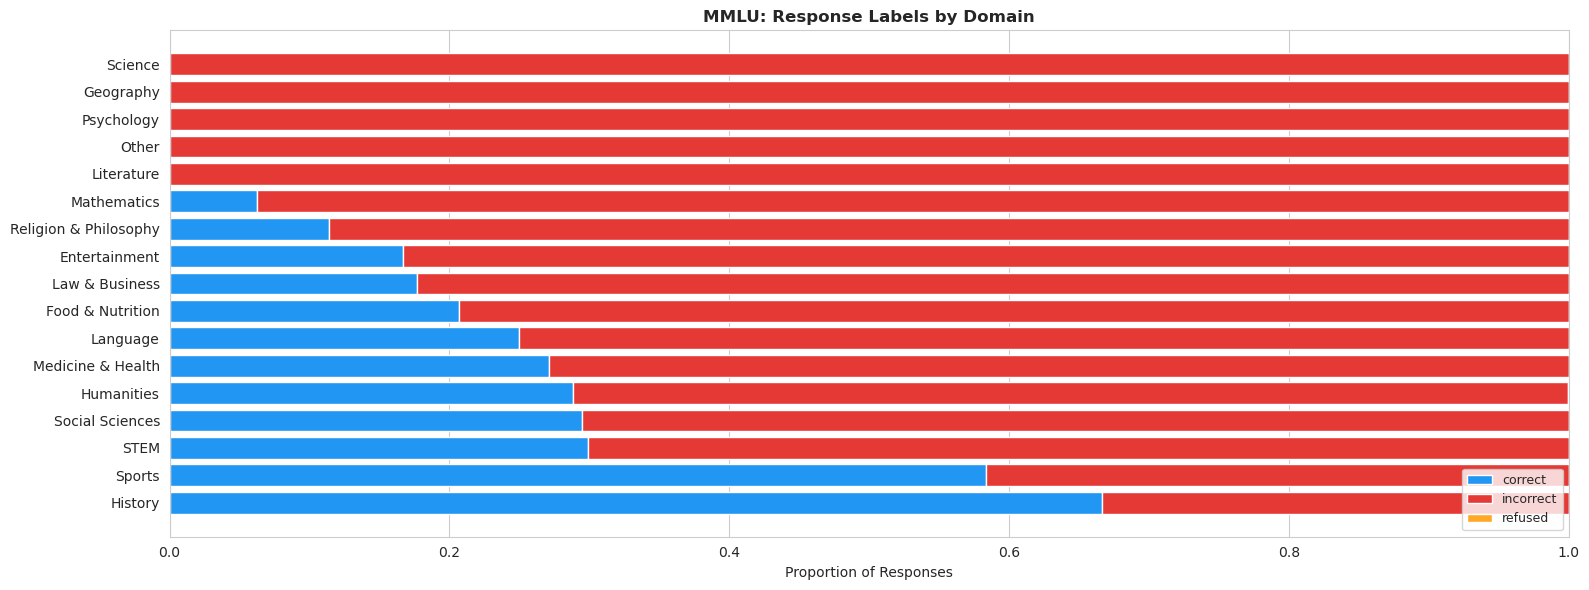


  TRIVIAQA
Dataset:          triviaqa
Total rows:       10000
Unique questions: 500
Samples/question: min=20, max=20, median=20.0

Correctness distribution:
  correct     :   5706  (57.1%)
  incorrect   :   4293  (42.9%)
  refused     :      1  (0.0%)

Domains (64 unique)  (showing 10 of 64):
  Automotive
  Automotive & Logos
  Automotive/Brand Logo
  Automotive/Branding
  Biology
  Design & Branding
  Entertainment
  Entertainment & Fiction
  Entertainment & Media
  Fashion
  ...
Domain inconsistency: 157/500 questions (31.4%)
Max unique domains per question: 4

Questions per domain (top 10):


domain_canonical
Humanities           248
STEM                 159
Social Sciences      125
Sports                30
Entertainment         25
Medicine & Health     15
History               15
Literature            14
Other                 14
Geography             13
Name: prompt_id, dtype: int64

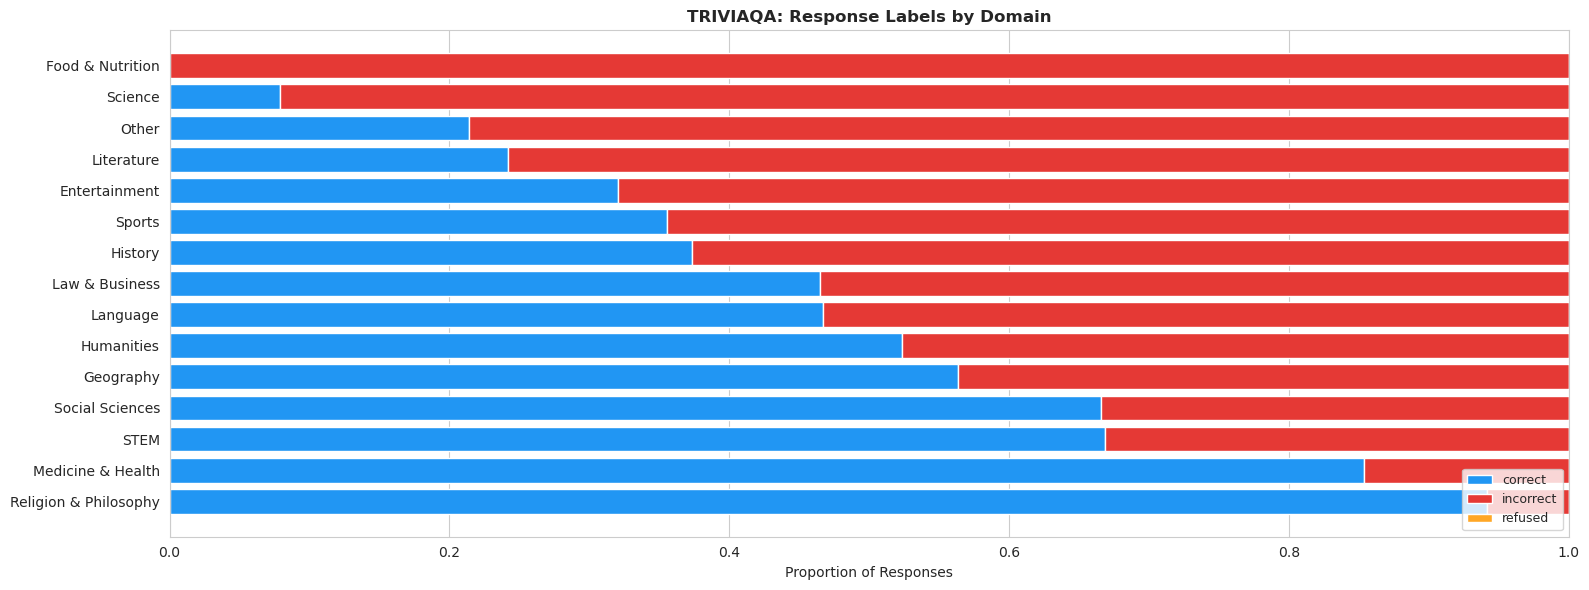


  TRUTHFULQA
Dataset:          truthfulqa
Total rows:       10000
Unique questions: 500
Samples/question: min=20, max=20, median=20.0

Correctness distribution:
  correct     :   2827  (28.3%)
  incorrect   :   7025  (70.2%)
  refused     :    148  (1.5%)

Domains (90 unique)  (showing 10 of 90):
  Agriculture
  Agriculture & Animal Welfare
  Animal Behavior
  Animal Behavior and Learning
  Animal Welfare
  Animal Welfare & Agriculture
  Animals & Wildlife
  Art & History
  Arts
  Arts and Culture
  ...
Domain inconsistency: 176/500 questions (35.2%)
Max unique domains per question: 5

Questions per domain (top 10):


domain_canonical
Social Sciences      218
Humanities           180
STEM                 136
Medicine & Health     61
Law & Business        45
Other                 18
Science               18
History               11
Entertainment          6
Geography              6
Name: prompt_id, dtype: int64

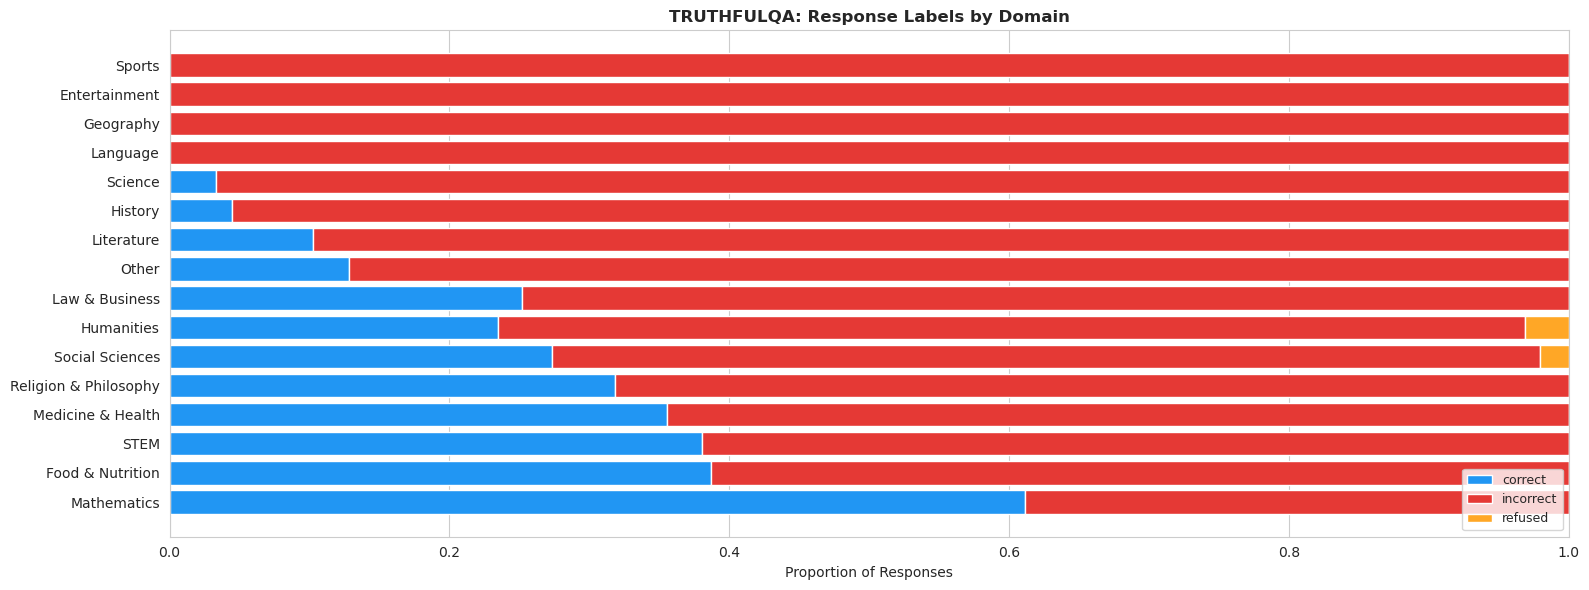

In [3]:
datasets = {}

for name, fname in DATASET_FILES.items():
    print(f"\n{'='*60}")
    print(f"  {name.upper()}")
    print(f"{'='*60}")

    df = load_dataset(os.path.join(DATA_DIR, fname))

    # Domain consolidation for noisy datasets
    domain_col = 'domain'
    if USE_CANONICAL[name]:
        df = add_canonical_domain(df)
        domain_col = 'domain_canonical'

    print_loading_summary(df)

    q_meta = compute_question_metadata(df, domain_col=domain_col)
    print_domain_consistency(q_meta)
    print('\nQuestions per domain (top 10):')
    display(questions_per_domain(df, domain_col=domain_col).head(10))

    # Response-level label breakdown
    fig = plot_response_label_breakdown(
        df, domain_col=domain_col,
        show_type_panel=(name == 'defan'),
        title_prefix=f'{name.upper()}: Response Labels',
    )
    plt.savefig(os.path.join(OUTPUT_DIR, f'{name}_response_labels.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

    datasets[name] = df

---
## Combined Dataset (All 5 Benchmarks: 2500 questions)

We concatenate all five feature DataFrames (loaded from `../data/temp/processed_csv/`
after feature_extraction.ipynb has been run) and repeat the EDA on the full pool.

In [4]:
df_all = pd.concat(datasets.values(), ignore_index=True)
print(f'Combined: {len(df_all):,} responses, {df_all["prompt_id"].nunique():,} questions')

# Overall correctness
print('\nResponse-level breakdown:')
for lab in LABEL_ORDER:
    vc = df_all['correctness'].value_counts()
    if lab in vc.index:
        print(f'  {lab:12s}: {vc[lab]:7,}  ({vc[lab]/len(df_all)*100:.1f}%)')

Combined: 50,000 responses, 2,500 questions

Response-level breakdown:
  correct     :  22,626  (45.3%)
  incorrect   :  27,212  (54.4%)
  refused     :     162  (0.3%)


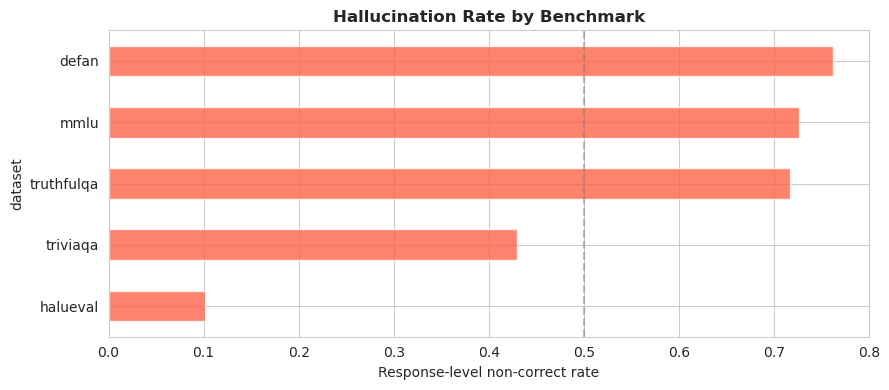

In [5]:
# Hallucination rate by benchmark
fig, ax = plt.subplots(figsize=(9, 4))
hallu_by_ds = (
    df_all.groupby('dataset')['correctness']
    .apply(lambda s: (s != 'correct').mean())
    .sort_values()
)
hallu_by_ds.plot(kind='barh', ax=ax, color='tomato', alpha=0.8)
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Response-level non-correct rate')
ax.set_title('Hallucination Rate by Benchmark', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'combined_hallu_by_dataset.png'), dpi=150, bbox_inches='tight')
plt.show()

The bar chart above compares the response-level non-correct rate across the five benchmarks. Differences here reflect a combination of genuine difficulty, the LLM's domain knowledge, and how strictly GPT-4.1-nano evaluates factuality for each benchmark's style of question.